In [1]:
# ============================================================
# NOTEBOOK 04: MODEL EVALUATION AND THRESHOLD TUNING
# ImmuniWatch Nigeria | AIRS Production System
# ============================================================

import os

os.chdir(r'C:\Users\USER\Desktop\immuniwatch_project')
os.makedirs('data/monitoring', exist_ok=True)

print(f"Working directory: {os.getcwd()}")
#print("Setup complete")

Working directory: C:\Users\USER\Desktop\immuniwatch_project


In [2]:
import json
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
#print("Libraries loaded successfully")

Device: cpu


In [3]:
CONFIG = {
    'model_path': 'models/misinfo/production/v1',
    'test_data_path': 'data/splits/test.csv',
    'max_length': 128,
    'batch_size': 32,
    'label2id': {'Misinformation': 0, 'Factual': 1, 'Uncertain': 2},
    'id2label': {0: 'Misinformation', 1: 'Factual', 2: 'Uncertain'}
}

print("Configuration loaded")
print(f"Model path: {CONFIG['model_path']}")
print(f"Test data:  {CONFIG['test_data_path']}")

Configuration loaded
Model path: models/misinfo/production/v1
Test data:  data/splits/test.csv


In [4]:
#loading test data

test_df = pd.read_csv(CONFIG['test_data_path'])
test_df['predicted_label'] = test_df['predicted_label'].str.strip().str.capitalize()
test_df['label_id'] = test_df['predicted_label'].map(CONFIG['label2id'])

text_col = 'clean_Text' if 'clean_Text' in test_df.columns else 'Tweet_Text'
test_df[text_col] = test_df[text_col].fillna('').astype(str)

print(f"Test set size: {len(test_df):,} rows")
print(f"Text column:   {text_col}")
print(f"\nLabel distribution:")
print(test_df['predicted_label'].value_counts())

Test set size: 1,751 rows
Text column:   Tweet_Text

Label distribution:
predicted_label
Uncertain         970
Factual           673
Misinformation    108
Name: count, dtype: int64


In [5]:
print("=== LOADING TRAINED MODEL ===")

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_path'])
model = AutoModelForSequenceClassification.from_pretrained(CONFIG['model_path'])
model = model.to(device)
model.eval()

print(f"Model loaded from: {CONFIG['model_path']}")
print(f"Labels: {model.config.id2label}")

=== LOADING TRAINED MODEL ===


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded from: models/misinfo/production/v1
Labels: {0: 'Misinformation', 1: 'Factual', 2: 'Uncertain'}


In [6]:
print("=== RUNNING INFERENCE ON TEST SET ===")

all_probs = []
all_labels = test_df['label_id'].tolist()
texts = test_df[text_col].tolist()

for i in range(0, len(texts), CONFIG['batch_size']):
    batch_texts = texts[i:i + CONFIG['batch_size']]

    encoding = tokenizer(
        batch_texts,
        max_length=CONFIG['max_length'],
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

    probs = F.softmax(outputs.logits, dim=1)
    all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
default_preds = np.argmax(all_probs, axis=1)

print(f"Inference complete on {len(texts):,} samples")

=== RUNNING INFERENCE ON TEST SET ===
Inference complete on 1,751 samples


In [7]:
print("=== BASELINE EVALUATION AT DEFAULT THRESHOLD (0.5) ===")

print(classification_report(
    all_labels,
    default_preds,
    target_names=['Misinformation', 'Factual', 'Uncertain']
))

baseline_recall = recall_score(
    all_labels, default_preds,
    labels=[0], average='macro'
)

print(f"Misinformation Recall: {baseline_recall:.4f}")
print(f"AIRS KPI Target:       0.75")

if baseline_recall >= 0.75:
    print("AIRS Recall KPI MET at default threshold")
else:
    print("Threshold tuning needed to meet AIRS KPI")

=== BASELINE EVALUATION AT DEFAULT THRESHOLD (0.5) ===
                precision    recall  f1-score   support

Misinformation       0.87      0.84      0.85       108
       Factual       0.96      0.98      0.97       673
     Uncertain       0.98      0.97      0.97       970

      accuracy                           0.96      1751
     macro avg       0.93      0.93      0.93      1751
  weighted avg       0.96      0.96      0.96      1751

Misinformation Recall: 0.8426
AIRS KPI Target:       0.75
AIRS Recall KPI MET at default threshold


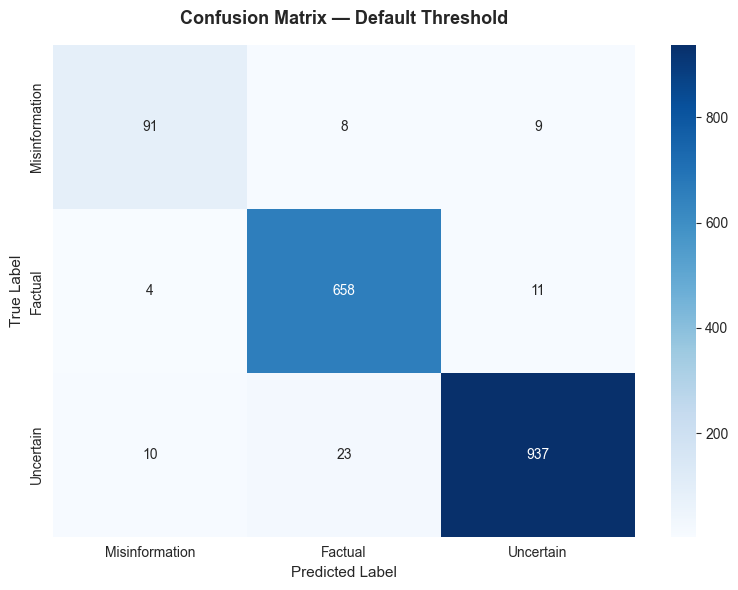

Saved: data/monitoring/confusion_matrix_default.png


In [8]:
cm = confusion_matrix(all_labels, default_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Misinformation', 'Factual', 'Uncertain'],
    yticklabels=['Misinformation', 'Factual', 'Uncertain'],
    ax=ax
)
ax.set_title('Confusion Matrix — Default Threshold',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig('data/monitoring/confusion_matrix_default.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/confusion_matrix_default.png")

In [9]:
print("=== THRESHOLD TUNING FOR MISINFORMATION CLASS ===")

misinfo_probs = all_probs[:, 0]
thresholds = np.arange(0.10, 0.90, 0.05)
results = []

for threshold in thresholds:
    tuned_preds = default_preds.copy()
    tuned_preds[misinfo_probs >= threshold] = 0

    misinfo_recall = recall_score(
        all_labels, tuned_preds,
        labels=[0], average='macro'
    )
    misinfo_precision = precision_score(
        all_labels, tuned_preds,
        labels=[0], average='macro',
        zero_division=0
    )
    macro_f1 = f1_score(
        all_labels, tuned_preds,
        average='macro'
    )

    results.append({
        'threshold': round(float(threshold), 2),
        'misinfo_recall': round(misinfo_recall, 4),
        'misinfo_precision': round(misinfo_precision, 4),
        'macro_f1': round(macro_f1, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

=== THRESHOLD TUNING FOR MISINFORMATION CLASS ===
 threshold  misinfo_recall  misinfo_precision  macro_f1
      0.10          0.8611             0.8378    0.9290
      0.15          0.8426             0.8349    0.9251
      0.20          0.8426             0.8349    0.9251
      0.25          0.8426             0.8349    0.9251
      0.30          0.8426             0.8349    0.9251
      0.35          0.8426             0.8667    0.9311
      0.40          0.8426             0.8667    0.9311
      0.45          0.8426             0.8667    0.9311
      0.50          0.8426             0.8667    0.9311
      0.55          0.8426             0.8667    0.9311
      0.60          0.8426             0.8667    0.9311
      0.65          0.8426             0.8667    0.9311
      0.70          0.8426             0.8667    0.9311
      0.75          0.8426             0.8667    0.9311
      0.80          0.8426             0.8667    0.9311
      0.85          0.8426             0.8667    0.931

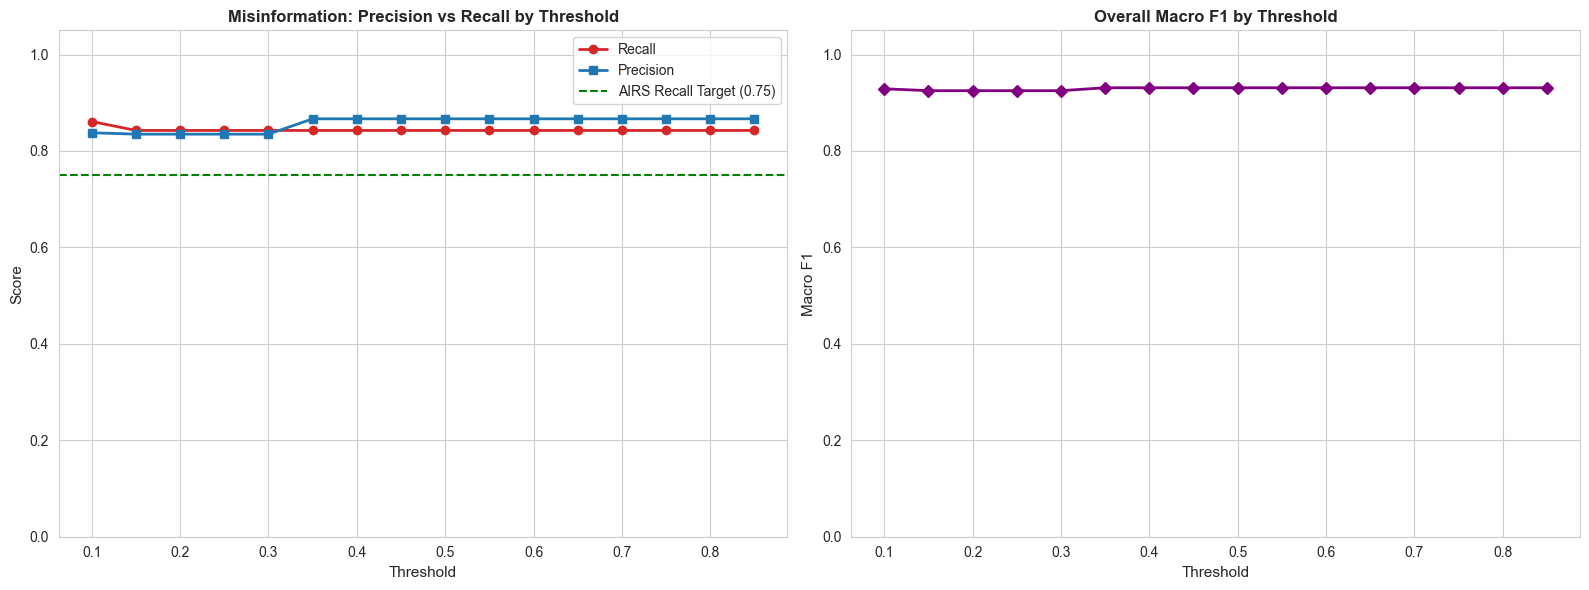

Saved: data/monitoring/threshold_tuning.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(
    results_df['threshold'],
    results_df['misinfo_recall'],
    marker='o', color='#d62728',
    linewidth=2, label='Recall'
)
axes[0].plot(
    results_df['threshold'],
    results_df['misinfo_precision'],
    marker='s', color='#1f77b4',
    linewidth=2, label='Precision'
)
axes[0].axhline(
    y=0.75, color='green',
    linestyle='--', linewidth=1.5,
    label='AIRS Recall Target (0.75)'
)
axes[0].set_title(
    'Misinformation: Precision vs Recall by Threshold',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Threshold', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 1.05)

axes[1].plot(
    results_df['threshold'],
    results_df['macro_f1'],
    marker='D', color='purple', linewidth=2
)
axes[1].set_title(
    'Overall Macro F1 by Threshold',
    fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Threshold', fontsize=11)
axes[1].set_ylabel('Macro F1', fontsize=11)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('data/monitoring/threshold_tuning.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/threshold_tuning.png")

In [11]:
print("=== SELECTING BEST THRESHOLD ===")

qualified = results_df[results_df['misinfo_recall'] >= 0.75]

if len(qualified) > 0:
    best_row = qualified.loc[qualified['macro_f1'].idxmax()]
    best_threshold = float(best_row['threshold'])
    print(f"Best threshold selected:  {best_threshold}")
    print(f"Misinformation Recall:    {best_row['misinfo_recall']}")
    print(f"Misinformation Precision: {best_row['misinfo_precision']}")
    print(f"Macro F1:                 {best_row['macro_f1']}")
    print(f"\n Recall KPI (>=0.75): MET")
else:
    best_threshold = 0.5
    print("No threshold meets recall >= 0.75")
    print(f"Using default threshold: {best_threshold}")

=== SELECTING BEST THRESHOLD ===
Best threshold selected:  0.35
Misinformation Recall:    0.8426
Misinformation Precision: 0.8667
Macro F1:                 0.9311

 Recall KPI (>=0.75): MET


In [12]:
print(f"=== FINAL EVALUATION AT THRESHOLD {best_threshold} ===")

final_preds = default_preds.copy()
final_preds[all_probs[:, 0] >= best_threshold] = 0

print(classification_report(
    all_labels,
    final_preds,
    target_names=['Misinformation', 'Factual', 'Uncertain']
))

=== FINAL EVALUATION AT THRESHOLD 0.35 ===
                precision    recall  f1-score   support

Misinformation       0.87      0.84      0.85       108
       Factual       0.96      0.98      0.97       673
     Uncertain       0.98      0.97      0.97       970

      accuracy                           0.96      1751
     macro avg       0.93      0.93      0.93      1751
  weighted avg       0.96      0.96      0.96      1751



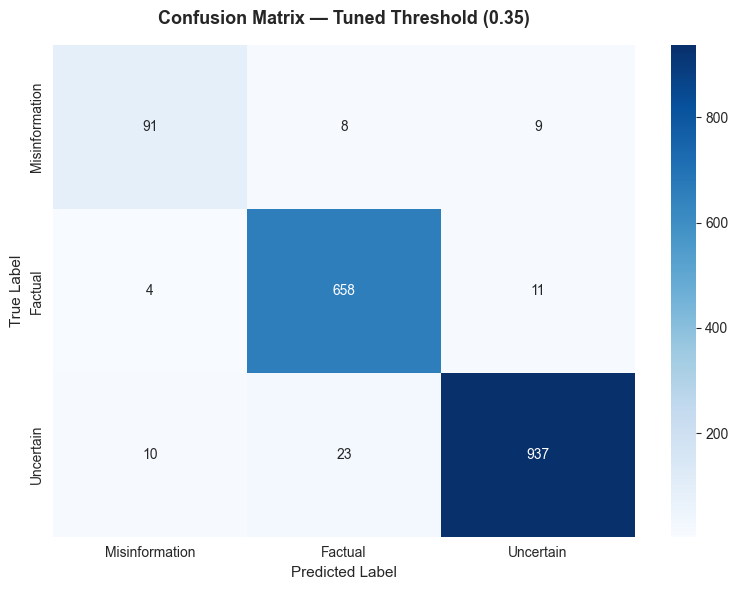

Saved: data/monitoring/confusion_matrix_tuned.png


In [13]:
cm_final = confusion_matrix(all_labels, final_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_final, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Misinformation', 'Factual', 'Uncertain'],
    yticklabels=['Misinformation', 'Factual', 'Uncertain'],
    ax=ax
)
ax.set_title(
    f'Confusion Matrix — Tuned Threshold ({best_threshold})',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig('data/monitoring/confusion_matrix_tuned.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/monitoring/confusion_matrix_tuned.png")

In [14]:
#print("=== SAVING ALL RESULTS ===")

# Add predictions and probabilities to test dataframe
test_df['pred_label_id'] = final_preds
test_df['pred_label'] = [CONFIG['id2label'][p] for p in final_preds]
test_df['prob_misinformation'] = all_probs[:, 0]
test_df['prob_factual'] = all_probs[:, 1]
test_df['prob_uncertain'] = all_probs[:, 2]
test_df['confidence'] = np.max(all_probs, axis=1)

test_df.to_csv('data/monitoring/evaluation_results.csv', index=False)
print("Saved: data/monitoring/evaluation_results.csv")

# Save threshold config for production use
threshold_config = {
    'best_threshold': best_threshold,
    'label2id': CONFIG['label2id'],
    'id2label': CONFIG['id2label'],
    'model_path': CONFIG['model_path'],
    'max_length': CONFIG['max_length']
}

with open('data/splits/threshold_config.json', 'w') as f:
    json.dump(threshold_config, f, indent=2)

print("Saved: data/splits/threshold_config.json")

# Save performance metrics
final_recall = recall_score(
    all_labels, final_preds, labels=[0], average='macro'
)
final_precision = precision_score(
    all_labels, final_preds, labels=[0],
    average='macro', zero_division=0
)
final_f1 = f1_score(all_labels, final_preds, average='macro')
accuracy = float(np.mean(all_labels == final_preds))

metrics = {
    'model': 'xlm-roberta-base',
    'best_threshold': best_threshold,
    'accuracy': round(accuracy, 4),
    'macro_f1': round(final_f1, 4),
    'misinformation_recall': round(final_recall, 4),
    'misinformation_precision': round(final_precision, 4),
    'airs_kpi_precision_met': bool(final_precision >= 0.85),
    'airs_kpi_recall_met': bool(final_recall >= 0.75)
}

with open('data/monitoring/performance_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Saved: data/monitoring/performance_metrics.json")

Saved: data/monitoring/evaluation_results.csv
Saved: data/splits/threshold_config.json
Saved: data/monitoring/performance_metrics.json
